# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02 (WEEK 1)
## Ứng dụng 3: Phân loại Hành vi Khuyến nghị & Sắc thái Bình luận (Recommendation / Sentiment Prediction)
**Tập dữ liệu:** `Womens Clothing E-Commerce Reviews.csv` (22,641 mẫu văn bản hợp lệ)  
**Đầu vào (Input):** Văn bản bình luận (`Title` + `Review Text`) mã hóa qua TF-IDF  
**Mục tiêu (Target):** `Recommended IND` (1: Khuyên mua / Tích cực, 0: Không khuyên mua / Tiêu cực)  
**Mô hình huấn luyện & so sánh:** 6 mô hình ML (Logistic Regression, Linear SVM, Multinomial Naive Bayes, Decision Tree, Random Forest, SGD Classifier) kèm xử lý mất cân bằng lớp.

---
### 1. Khởi tạo Môi trường & Nạp Dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# 6 Mô hình ML phân loại nhị phân
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Thiết lập hiển thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_raw = pd.read_csv('data/Womens Clothing E-Commerce Reviews.csv')
print(f"✅ Tải dữ liệu thành công: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")

✅ Tải dữ liệu thành công: 23,486 dòng, 11 cột


---
### 2. Tiền xử lý Dữ liệu & Xử lý Mất cân bằng Lớp (Data Preparation)

In [2]:
# 1. Loại bỏ các dòng trống Review Text
df = df_raw.dropna(subset=['Review Text']).copy()

# 2. Kết hợp Title và Review Text
df['Clean_Title'] = df['Title'].fillna('')
df['Full_Text'] = df['Clean_Title'] + ' ' + df['Review Text']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Text'] = df['Full_Text'].apply(clean_text)

# 3. Thống kê phân bố nhãn mục tiêu
rec_counts = df['Recommended IND'].value_counts()
print(f"Tổng số mẫu sau khi làm sạch: {len(df):,} mẫu")
print(f"  • Nhãn 1 (Khuyên mua / Tích cực)    : {rec_counts[1]:,} mẫu ({rec_counts[1]/len(df)*100:.1f}%)")
print(f"  • Nhãn 0 (Không khuyên / Tiêu cực) : {rec_counts[0]:,} mẫu ({rec_counts[0]/len(df)*100:.1f}%)")
print(f"  • Tỷ lệ mất cân bằng lớp: ~ 4.6 : 1 (Cần áp dụng class_weight='balanced')")

Tổng số mẫu sau khi làm sạch: 22,641 mẫu
  • Nhãn 1 (Khuyên mua / Tích cực)    : 18,540 mẫu (81.9%)
  • Nhãn 0 (Không khuyên / Tiêu cực) : 4,101 mẫu (18.1%)
  • Tỷ lệ mất cân bằng lớp: ~ 4.6 : 1 (Cần áp dụng class_weight='balanced')


---
### 3. Phân chia Train/Test & Biểu diễn Đặc trưng TF-IDF

In [3]:
# 1. Phân chia 80% Train - 20% Test (Stratified)
X_text = df['Clean_Text'].values
y = df['Recommended IND'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Trích xuất đặc trưng TF-IDF (N-gram 1-2, 3500 features)
tfidf_vec = TfidfVectorizer(
    max_features=3500,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    norm='l2'
)

X_train = tfidf_vec.fit_transform(X_train_raw)
X_test = tfidf_vec.transform(X_test_raw)

print(f"✅ Ma trận Train (X_train): {X_train.shape[0]:,} mẫu x {X_train.shape[1]:,} đặc trưng")
print(f"✅ Ma trận Test  (X_test) : {X_test.shape[0]:,} mẫu x {X_test.shape[1]:,} đặc trưng")

✅ Ma trận Train (X_train): 18,112 mẫu x 3,500 đặc trưng
✅ Ma trận Test  (X_test) : 4,529 mẫu x 3,500 đặc trưng


---
### 4. Huấn luyện & Đánh giá So sánh 6 Mô hình Máy học

In [4]:
models = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42),
    "Linear SVM (Balanced)": LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "SGD Classifier (Balanced Log)": SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=25, class_weight='balanced', random_state=42),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=150, max_depth=25, class_weight='balanced', n_jobs=-1, random_state=42)
}

results_list = []
roc_curves_data = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    # Tính xác suất hoặc decision function để vẽ ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves_data[name] = (fpr, tpr, roc_auc)
    
    results_list.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "ROC-AUC": round(roc_auc, 4),
        "Training Time (s)": round(train_time, 3)
    })

df_results = pd.DataFrame(results_list).sort_values(by='F1-Score (%)', ascending=False)
print("=== BẢNG SO SÁNH HIỆU NĂNG 6 MÔ HÌNH DỰ ĐOÁN HÀNH VI KHUYẾN NGHỊ (RECOMMENDED IND) ===")
df_results

=== BẢNG SO SÁNH HIỆU NĂNG 6 MÔ HÌNH DỰ ĐOÁN HÀNH VI KHUYẾN NGHỊ (RECOMMENDED IND) ===


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC,Training Time (s)
2,Multinomial Naive Bayes,88.05,89.40,96.90,93.00,0.9322,0.003
5,Random Forest (Balanced),87.59,93.67,90.99,92.31,0.9092,0.566
0,Logistic Regression (Balanced),87.88,96.31,88.60,92.29,0.9403,0.035
3,SGD Classifier (Balanced Log),87.75,96.41,88.33,92.19,0.9402,0.040
1,Linear SVM (Balanced),86.99,94.70,89.11,91.82,0.9233,0.076
4,Decision Tree,78.01,91.09,81.07,85.79,0.7038,1.079


---
### 5. Trực quan hóa So sánh Hiệu năng & Đường cong ROC (ROC Curves)

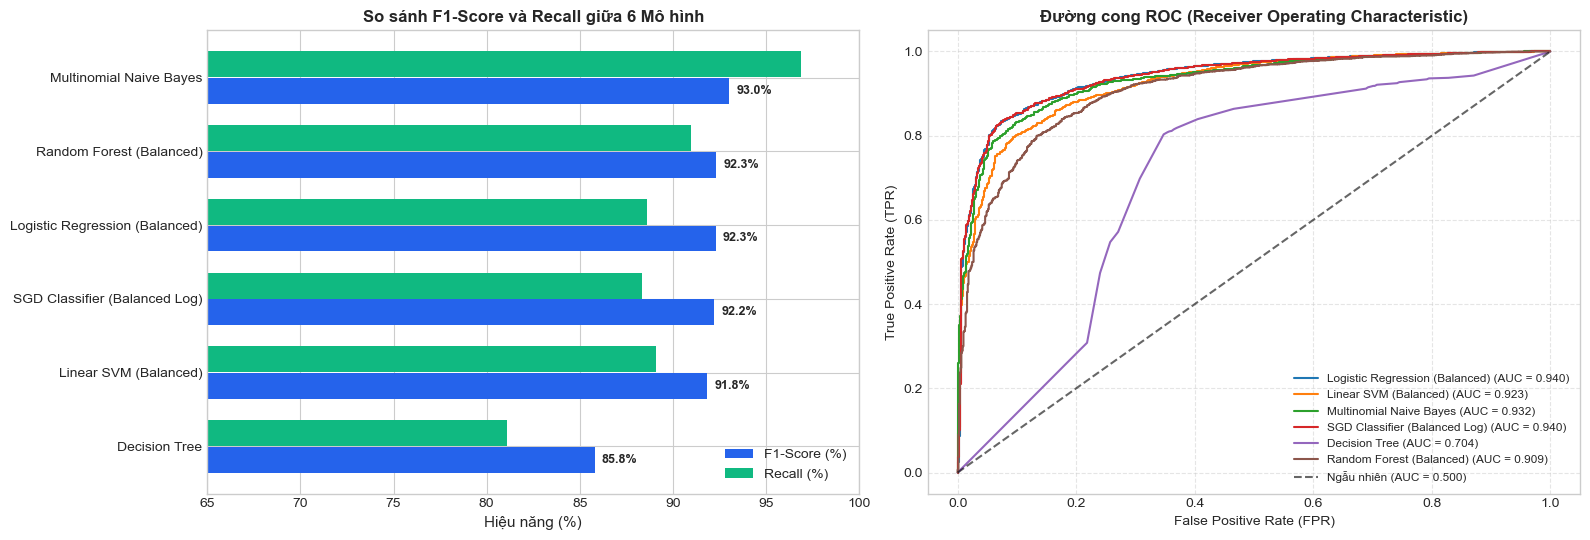

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Biểu đồ F1-Score & Recall
df_plot = df_results.sort_values(by='F1-Score (%)', ascending=True)
y_pos = np.arange(len(df_plot))

axes[0].barh(y_pos - 0.18, df_plot['F1-Score (%)'], height=0.35, label='F1-Score (%)', color='#2563eb')
axes[0].barh(y_pos + 0.18, df_plot['Recall (%)'], height=0.35, label='Recall (%)', color='#10b981')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['Model'], fontsize=10)
axes[0].set_xlabel('Hiệu năng (%)', fontsize=11)
axes[0].set_title('So sánh F1-Score và Recall giữa 6 Mô hình', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim(65, 100)
for i, v in enumerate(df_plot['F1-Score (%)']):
    axes[0].text(v + 0.4, i - 0.18, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')

# 2. Đường cong ROC Curves
for name, (fpr, tpr, auc_val) in roc_curves_data.items():
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=1.5)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Ngẫu nhiên (AUC = 0.500)')
axes[1].set_title('Đường cong ROC (Receiver Operating Characteristic)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc='lower right', fontsize=8.5)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
### 6. Đánh giá Chi tiết Mô hình Tốt nhất (Logistic Regression) & Confusion Matrix

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
                  precision    recall  f1-score   support

Không khuyên (0)       0.62      0.85      0.72       820
  Khuyên mua (1)       0.96      0.89      0.92      3709

        accuracy                           0.88      4529
       macro avg       0.79      0.87      0.82      4529
    weighted avg       0.90      0.88      0.89      4529



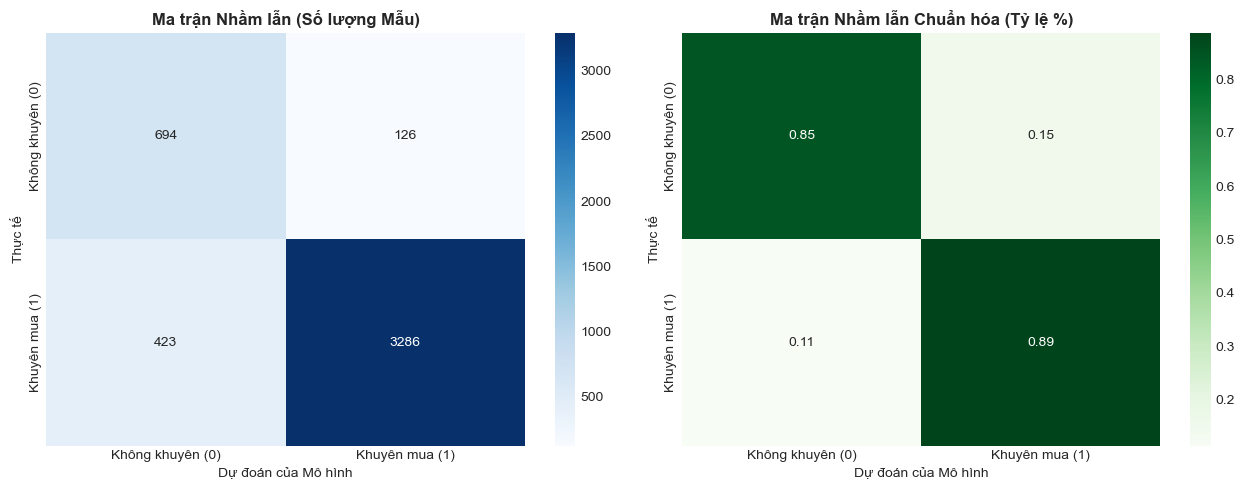

In [6]:
best_model = models["Logistic Regression (Balanced)"]
y_pred_best = best_model.predict(X_test)

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred_best, target_names=['Không khuyên (0)', 'Khuyên mua (1)']))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không khuyên (0)', 'Khuyên mua (1)'],
            yticklabels=['Không khuyên (0)', 'Khuyên mua (1)'])
axes[0].set_title('Ma trận Nhầm lẫn (Số lượng Mẫu)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dự đoán của Mô hình')
axes[0].set_ylabel('Thực tế')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Không khuyên (0)', 'Khuyên mua (1)'],
            yticklabels=['Không khuyên (0)', 'Khuyên mua (1)'])
axes[1].set_title('Ma trận Nhầm lẫn Chuẩn hóa (Tỷ lệ %)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dự đoán của Mô hình')
axes[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

---
### 7. Phân tích Trọng số Đặc trưng: Top Từ khóa Tích cực vs Tiêu cực

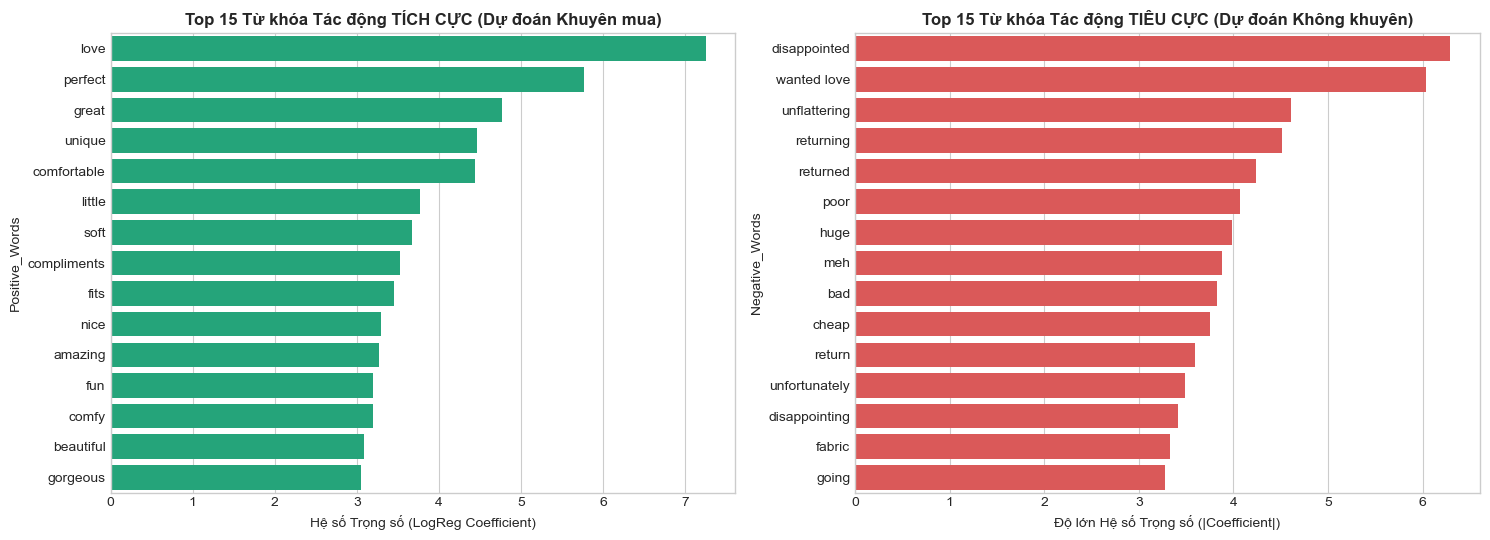

In [7]:
feature_names = np.array(tfidf_vec.get_feature_names_out())
coefs = best_model.coef_[0]

# Top 15 từ khóa tác động tích cực (khiến mô hình dự đoán KHUYÊN MUA)
top_pos_idx = np.argsort(coefs)[-15:][::-1]
# Top 15 từ khóa tác động tiêu cực (khiến mô hình dự đoán KHÔNG KHUYÊN MUA)
top_neg_idx = np.argsort(coefs)[:15]

df_top_features = pd.DataFrame({
    'Positive_Words': feature_names[top_pos_idx],
    'Pos_Weight': coefs[top_pos_idx],
    'Negative_Words': feature_names[top_neg_idx],
    'Neg_Weight': coefs[top_neg_idx]
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x='Pos_Weight', y='Positive_Words', data=df_top_features, ax=axes[0], color='#10b981')
axes[0].set_title('Top 15 Từ khóa Tác động TÍCH CỰC (Dự đoán Khuyên mua)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hệ số Trọng số (LogReg Coefficient)')

sns.barplot(x=df_top_features['Neg_Weight'].abs(), y='Negative_Words', data=df_top_features, ax=axes[1], color='#ef4444')
axes[1].set_title('Top 15 Từ khóa Tác động TIÊU CỰC (Dự đoán Không khuyên)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Độ lớn Hệ số Trọng số (|Coefficient|)')

plt.tight_layout()
plt.show()

---
### 8. Thử nghiệm Dự đoán Trực tiếp với Câu Bình luận Mới

In [8]:
sample_reviews = [
    "I absolutely adore this dress! The fabric is so soft, fits like a dream and I received tons of compliments.",
    "Very disappointed. Poor quality fabric, zipper broke on the first try and completely unflattering fit. Returned immediately.",
    "Decent top for everyday wear, but the color is slightly darker than pictured."
]

print("=== THỬ NGHIỆM DỰ ĐOÁN HÀNH VI KHUYẾN NGHỊ TỪ BÌNH LUẬN KHÁCH HÀNG ===")
for rev in sample_reviews:
    vec = tfidf_vec.transform([clean_text(rev)])
    pred_class = best_model.predict(vec)[0]
    pred_prob = best_model.predict_proba(vec)[0]
    
    label_str = "KHUYÊN MUA (Recommended)" if pred_class == 1 else "KHÔNG KHUYÊN MUA (Not Recommended)"
    
    print(f"\n📝 Review: \"{rev}\"")
    print(f"🎯 Dự đoán: ➔ [{label_str}]")
    print(f"📊 Xác suất: Khuyên mua = {pred_prob[1]*100:.1f}% | Không khuyên = {pred_prob[0]*100:.1f}%")

=== THỬ NGHIỆM DỰ ĐOÁN HÀNH VI KHUYẾN NGHỊ TỪ BÌNH LUẬN KHÁCH HÀNG ===

📝 Review: "I absolutely adore this dress! The fabric is so soft, fits like a dream and I received tons of compliments."
🎯 Dự đoán: ➔ [KHUYÊN MUA (Recommended)]
📊 Xác suất: Khuyên mua = 85.4% | Không khuyên = 14.6%

📝 Review: "Very disappointed. Poor quality fabric, zipper broke on the first try and completely unflattering fit. Returned immediately."
🎯 Dự đoán: ➔ [KHÔNG KHUYÊN MUA (Not Recommended)]
📊 Xác suất: Khuyên mua = 0.0% | Không khuyên = 100.0%

📝 Review: "Decent top for everyday wear, but the color is slightly darker than pictured."
🎯 Dự đoán: ➔ [KHUYÊN MUA (Recommended)]
📊 Xác suất: Khuyên mua = 85.1% | Không khuyên = 14.9%
